In [1]:
import numpy as np
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
from tqdm import tqdm
import os
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset
from sklearn.cluster import KMeans

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {torch.cuda.get_device_name(0)}')

Using device: NVIDIA GeForce RTX 5060 Ti


In [2]:
SEED = 42

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
    torch.use_deterministic_algorithms(True, warn_only=True)

set_seed(SEED)


## 1. Data Loading

Load hyperspectral data and treat each pixel as an independent sample.
NO spatial context is used.

In [3]:
def load_hsi_data(data_path):
    """Load HSI data from ENVI format."""
    import spectral
    img = spectral.open_image(data_path)
    data = img.load()
    return np.array(data, dtype=np.float32)

def load_label(label_path):
    """Load label data."""
    return np.load(label_path)

def calibrate_hsi(data, white_ref_path, dark_ref_path):
    """Calibrate HSI data while preserving the physical spatial lighting gradient."""
    import spectral
    import numpy as np
    
    white_ref = np.array(spectral.open_image(white_ref_path).load(), dtype=np.float32)
    dark_ref = np.array(spectral.open_image(dark_ref_path).load(), dtype=np.float32)
    
    # Average ONLY across the time/scan-line dimension (axis=0)
    # This leaves us with a 2D profile of the exact lighting across the scanner width
    # white_profile shape becomes: (512, 224)
    white_profile = white_ref.mean(axis=0) 
    dark_profile = dark_ref.mean(axis=0)
    
    # Numpy broadcasting magic: 
    # (400, 512, 224) - (512, 224) perfectly aligns the columns.
    # Column 0 is calibrated by the light bulb intensity at Column 0.
    calibrated = (data - dark_profile) / (white_profile - dark_profile + 1e-8)
    
    # Clip to physical reflectance bounds
    calibrated = np.clip(calibrated, 0, 1)
    
    return calibrated

In [4]:
class HSIPixelDataset(Dataset):
    """Dataset that treats each pixel as an independent sample."""
    
    def __init__(self, data, labels=None):
        """
        Args:
            data: HSI data of shape (H, W, B)
            labels: Label array of shape (H, W) or None
        """
        self.data = data
        self.labels = labels
        
        # Flatten spatial dimensions
        #H, W, B = data.shape
        self.pixels = self.data
        
        if labels is not None:
            self.pixel_labels = labels
        else:
            self.pixel_labels = None
        
        self.shape = (H, W)
    
    def __len__(self):
        return len(self.pixels)
    
    def __getitem__(self, idx):
        pixel = torch.from_numpy(self.pixels[idx]).float()
        
        if self.pixel_labels is not None:
            label = torch.tensor(self.pixel_labels[idx], dtype=torch.long)
            return pixel, label
        else:
            return pixel

In [5]:
# Load data for a specific food type
food_type = 'GarlicStems'  # Change to 'Pistachio' or 'GarlicStems' as needed

base_path = f'../../AnomalyonFood/Dataset/{food_type}'



# Load training data (normal only)
train_data_path = f'{base_path}/Train/data.hdr'
train_white_path = f'{base_path}/Train/WHITEREF.hdr'
train_dark_path = f'{base_path}/Train/DARKREF.hdr'

print(f'Loading {food_type} training data...')
train_data = load_hsi_data(train_data_path)
train_data = calibrate_hsi(train_data, train_white_path, train_dark_path)

#WN: coba hanya menggunakan X% data training
H, W, B = train_data.shape
train_data = train_data.reshape(-1, B)


X_train, X_test = train_test_split(train_data, test_size=0.7, random_state=42)

# Load test data (normal + anomalies)
test_data_path = f'{base_path}/Test/data.hdr'
test_white_path = f'{base_path}/Test/WHITEREF.hdr'
test_dark_path = f'{base_path}/Test/DARKREF.hdr'
test_label_path = f'{base_path}/Test/label.npy'


print(f'Loading {food_type} test data...')
test_data = load_hsi_data(test_data_path)
test_data = calibrate_hsi(test_data, test_white_path, test_dark_path)
test_labels = load_label(test_label_path)

H, W, B = test_data.shape
test_data = test_data.reshape(-1, B)
test_labels=test_labels.reshape(-1)

print(f'Train data shape: {train_data.shape}')
print(f'Test data shape: {test_data.shape}')
print(f'Test labels shape: {test_labels.shape}')
print(f'Number of bands: {train_data.shape[1]}')

Loading GarlicStems training data...


/home/alfi/miniforge3/envs/torch/lib/python3.13/site-packages/spectral/io/envi.py:187: UserWarning: Parameters with non-lowercase names encountered and converted to lowercase. To retain source file parameter name capitalization, set spectral.settings.envi_support_nonlowercase_params to True.
  warnings.warn(msg)


Loading GarlicStems test data...
Train data shape: (204800, 224)
Test data shape: (204800, 224)
Test labels shape: (204800,)
Number of bands: 224


In [6]:
# Create datasets
train_dataset = HSIPixelDataset(X_train)
test_dataset = HSIPixelDataset(test_data, test_labels)

print(f'Training pixels: {len(train_dataset)}')
print(f'Test pixels: {len(test_dataset)}')
print(f'Spectrum dimension: {train_dataset.pixels.shape[1]}')

# Create dataloaders
batch_size = 512
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=8)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=8)

Training pixels: 61440
Test pixels: 204800
Spectrum dimension: 224


## 2. PA2E Model Architecture

### Components:
1. **Sliding Window Extractor** (masked FC, non-trainable)
2. **Partial Encoders** (independent FC per window)
3. **Aggregate Encoder** (single FC layer)
4. **Decoder** (mirror of encoder, used only during training)

In [7]:
class SlidingWindowExtractor(nn.Module):
    """Extract sliding windows using masked FC (not convolution)."""
    
    def __init__(self, input_dim, window_size, stride):
        super().__init__()
        self.input_dim = input_dim
        self.window_size = window_size
        self.stride = stride
        
        # Calculate number of windows
        self.num_windows = 1 + (input_dim - window_size) // stride
        
        # Create fixed extraction matrix (non-trainable)
        # This is essentially an identity matrix that extracts windows
        self.register_buffer('extract_matrix', self._create_extract_matrix())
    
    def _create_extract_matrix(self):
        """Create a matrix that extracts sliding windows."""
        matrix = torch.zeros(self.num_windows * self.window_size, self.input_dim)
        
        for i in range(self.num_windows):
            start_idx = i * self.stride
            end_idx = start_idx + self.window_size
            
            # Set the corresponding block to identity
            for j in range(self.window_size):
                matrix[i * self.window_size + j, start_idx + j] = 1.0
        
        return matrix
    
    def forward(self, x):
        """
        Args:
            x: (batch, input_dim)
        Returns:
            windows: (batch, num_windows, window_size)
        """
        # Extract windows via matrix multiplication
        windows = torch.matmul(x, self.extract_matrix.t())  # (batch, num_windows * window_size)
        
        # Reshape to separate windows
        batch_size = x.size(0)
        windows = windows.view(batch_size, self.num_windows, self.window_size)
        
        return windows

In [8]:
class PartialEncodersConv1D(nn.Module):
    """Lean Conv1D encoders with GAP to 2 bins (14 channels × 2 bins = 28 dims)."""
    
    def __init__(self, num_windows, window_size, latent_local_dim):
        super().__init__()
        self.num_windows = num_windows
        self.window_size = window_size
        self.latent_local_dim = latent_local_dim
        
        # Create independent Conv1D encoders for each window
        self.encoders = nn.ModuleList([
            nn.Sequential(
                # Input: (batch, 1, 56)
                # Stride=2 halves the length: 56 -> 28
                nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3, stride=2, padding=1),
                nn.BatchNorm1d(16),
                nn.ReLU(),
                
                # Stride=2 halves again: 28 -> 14
                # Output channels fixed to 14 so 14 * 2 bins = 28 dims after GAP(2)
                nn.Conv1d(in_channels=16, out_channels=14, kernel_size=3, stride=2, padding=1),
                nn.BatchNorm1d(14),
                nn.ReLU(),
                
                # Global Average Pooling to 2 bins: (batch, 14, 14) -> (batch, 14, 2)
                nn.AdaptiveAvgPool1d(output_size=2),
                
                # Flatten: (batch, 14, 2) -> (batch, 28)
                nn.Flatten(start_dim=1, end_dim=-1)
            )
            for _ in range(num_windows)
        ])
    
    def forward(self, windows):
        """
        Args:
            windows: (batch, num_windows, window_size)
        Returns:
            local_latents: (batch, num_windows, latent_local_dim)
        """
        batch_size = windows.size(0)
        local_latents = []
        
        for i in range(self.num_windows):
            # Extract window i and add channel dimension: (batch, 56) -> (batch, 1, 56)
            window_i = windows[:, i, :].unsqueeze(1)
            
            # Encode with independent encoder i
            latent_i = self.encoders[i](window_i)
            local_latents.append(latent_i)
        
        # Stack latents
        local_latents = torch.stack(local_latents, dim=1)  # (batch, num_windows, latent_local_dim)
        
        return local_latents

In [9]:
class PartialDecodersConv1D(nn.Module):
    """Lean Conv1D decoders symmetric to encoder with 14 channels × 2 bins input."""
    
    def __init__(self, num_windows, window_size, latent_local_dim):
        super().__init__()
        self.num_windows = num_windows
        self.window_size = window_size
        self.latent_local_dim = latent_local_dim
        
        # Create independent Conv1D decoders for each window
        self.decoders = nn.ModuleList([
            nn.Sequential(
                # Input: (batch, latent_local_dim=28)
                # Reshape to 3D tensor: (batch, 14, 2)
                nn.Unflatten(dim=1, unflattened_size=(14, 2)),
                
                # Expand bins to sequence length 14: (batch, 14, 2) -> (batch, 14, 14)                
                nn.Upsample(size=14, mode='nearest'),
                
                # Upsample length: 14 -> 28, channels: 14 -> 16
                nn.ConvTranspose1d(in_channels=14, out_channels=16, kernel_size=4, stride=2, padding=1),
                nn.BatchNorm1d(16),
                nn.ReLU(),
                
                # Upsample length: 28 -> 56, channels: 16 -> 1
                nn.ConvTranspose1d(in_channels=16, out_channels=1, kernel_size=4, stride=2, padding=1)
                # No ReLU here - allow raw value reconstruction to match input distribution
            )
            for _ in range(num_windows)
        ])
    
    def forward(self, local_latents):
        """
        Args:
            local_latents: (batch, num_windows, latent_local_dim)
        Returns:
            reconstructed_windows: (batch, num_windows, window_size)
        """
        batch_size = local_latents.size(0)
        reconstructed = []
        
        for i in range(self.num_windows):
            latent_i = local_latents[:, i, :]  # (batch, latent_local_dim)
            # Decode and remove channel dimension: (batch, 1, 56) -> (batch, 56)
            recon_i = self.decoders[i](latent_i).squeeze(1)
            reconstructed.append(recon_i)
        
        reconstructed = torch.stack(reconstructed, dim=1)  # (batch, num_windows, window_size)
        
        return reconstructed

In [10]:
class PA2E(nn.Module):
    """PA2E model with Conv1D partial encoders/decoders."""
    
    def __init__(self, input_dim, window_size=56, stride=14, 
                 latent_local_dim=32, latent_global_dim=64):
        super().__init__()
        
        self.input_dim = input_dim
        self.window_size = window_size
        self.stride = stride
        self.latent_global_dim = latent_global_dim
        
        # 1. Sliding window extractor (non-trainable)
        self.window_extractor = SlidingWindowExtractor(input_dim, window_size, stride)
        num_windows = self.window_extractor.num_windows
        
        print(f'Number of windows: {num_windows}')
        
        # 2. Partial encoders (Conv1D with stride-2 downsampling)
        self.partial_encoders = PartialEncodersConv1D(num_windows, window_size, latent_local_dim)
        
        # 3. Aggregate encoder (SINGLE FC layer)
        concat_dim = num_windows * latent_local_dim
        self.aggregate_encoder = nn.Linear(concat_dim, latent_global_dim)
        
        # 4. Aggregate decoder (mirror of aggregate encoder)
        self.aggregate_decoder = nn.Linear(latent_global_dim, concat_dim)
        
        # 5. Partial decoders (Conv1D with ConvTranspose1d upsampling)
        self.partial_decoders = PartialDecodersConv1D(num_windows, window_size, latent_local_dim)
        
        # Center for DSVDD (initialized later)
        self.register_buffer('center', torch.zeros(latent_global_dim))
        self.center_initialized = False
    
    def encode(self, x):
        """Encode input to latent representation."""
        # Extract windows
        windows = self.window_extractor(x)  # (batch, num_windows, window_size)
        
        # Encode each window independently
        local_latents = self.partial_encoders(windows)  # (batch, num_windows, latent_local_dim)
        
        # Concatenate local latents
        batch_size = x.size(0)
        z_concat = local_latents.view(batch_size, -1)  # (batch, num_windows * latent_local_dim)
        
        # Aggregate
        z = self.aggregate_encoder(z_concat)  # (batch, latent_global_dim)
        
        return z, local_latents
    
    def decode(self, z):
        """Decode latent to reconstruction."""
        # Aggregate decoder
        z_concat = self.aggregate_decoder(z)  # (batch, num_windows * latent_local_dim)
        
        # Reshape to local latents
        batch_size = z.size(0)
        num_windows = self.window_extractor.num_windows
        latent_local_dim = z_concat.size(1) // num_windows
        local_latents = z_concat.view(batch_size, num_windows, latent_local_dim)
        
        # Decode each window independently
        reconstructed_windows = self.partial_decoders(local_latents)
        
        return reconstructed_windows
    
    def forward(self, x):
        """Forward pass."""
        z, local_latents = self.encode(x)
        reconstructed_windows = self.decode(z)
        
        return z, reconstructed_windows
    
    def compute_anomaly_score(self, x):
        """Compute anomaly score as distance to center."""
        z, _ = self.encode(x)
        
        # Distance to center
        dist = torch.sum((z - self.center) ** 2, dim=1)
        
        return dist


In [11]:
class PA2EFT(PA2E):
    """Fine-tuning wrapper for PA2E with Conv1D components."""
    def __init__(self, pa2e: PA2E):
        # Initialize parent with same architecture parameters
        super().__init__(
            input_dim=pa2e.input_dim,
            window_size=pa2e.window_size,
            stride=pa2e.stride,
            latent_local_dim=28,  # Fixed for Conv1D
            latent_global_dim=pa2e.latent_global_dim,
        )
        # Copy all weights from pa2e
        self.load_state_dict(pa2e.state_dict())
    
    def encode(self, x):
        """Encode input to latent representation."""
        # Extract windows
        windows = self.window_extractor(x)  # (batch, num_windows, window_size)
        
        # Encode each window independently
        local_latents = self.partial_encoders(windows)  # (batch, num_windows, latent_local_dim)
        
        # Concatenate local latents
        batch_size = x.size(0)
        z_concat = local_latents.view(batch_size, -1)  # (batch, num_windows * latent_local_dim)
        
        # Aggregate
        z = self.aggregate_encoder(z_concat)  # (batch, latent_global_dim)
        
        return z, local_latents
    
    def decode(self, local_latents):
        """Decode latent to reconstruction."""
        
        # Decode each window independently
        reconstructed_windows = self.partial_decoders(local_latents)
        
        return reconstructed_windows
    
    def forward(self, x):
        """Forward pass."""
        z, local_latents = self.encode(x)
        reconstructed_windows = self.decode(local_latents)
        
        return z, reconstructed_windows
    
    def compute_anomaly_score(self, x):
        """Compute anomaly score as distance to center."""
        z, _ = self.encode(x)
        
        # Distance to center
        dist = torch.sum((z - self.center) ** 2, dim=1)
        
        return dist


In [12]:
# Initialize model
input_dim = train_dataset.pixels.shape[1]

model = PA2E(
    input_dim=input_dim,
    window_size=56,
    stride=14,
    #hidden_dim=128,
    latent_local_dim=28,
    latent_global_dim=32
).to(device)

print(model)
print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

Number of windows: 13
PA2E(
  (window_extractor): SlidingWindowExtractor()
  (partial_encoders): PartialEncodersConv1D(
    (encoders): ModuleList(
      (0-12): 13 x Sequential(
        (0): Conv1d(1, 16, kernel_size=(3,), stride=(2,), padding=(1,))
        (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Conv1d(16, 14, kernel_size=(3,), stride=(2,), padding=(1,))
        (4): BatchNorm1d(14, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU()
        (6): AdaptiveAvgPool1d(output_size=2)
        (7): Flatten(start_dim=1, end_dim=-1)
      )
    )
  )
  (aggregate_encoder): Linear(in_features=364, out_features=32, bias=True)
  (aggregate_decoder): Linear(in_features=32, out_features=364, bias=True)
  (partial_decoders): PartialDecodersConv1D(
    (decoders): ModuleList(
      (0-12): 13 x Sequential(
        (0): Unflatten(dim=1, unflattened_size=(14, 2))
        (1): Upsample(size=14,

## 3. Training Procedure

### Phase 1: Pre-training (Autoencoder)
Train with reconstruction loss only to learn stable representations.

In [13]:
def compute_reconstruction_loss(model, x):
    """Compute reconstruction loss for sliding windows."""
    # Forward pass
    z, reconstructed_windows = model(x)
    
    # Extract original windows
    original_windows = model.window_extractor(x)
    
    # MSE loss
    loss = F.mse_loss(reconstructed_windows, original_windows)
    
    return loss, z

def train_phase1(model, train_loader, num_epochs=20, lr=1e-3):
    """Phase 1: Pre-training with reconstruction loss + OneCycleLR.
    
    OneCycleLR drives aggressive exploration so the Conv1D filters can
    learn the broad chemical-signature shapes without collapsing onto
    background noise.
    """
    print('\n=== Phase 1: Pre-training (Autoencoder + OneCycleLR) ===')
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=lr,
        epochs=num_epochs,
        steps_per_epoch=len(train_loader),
        pct_start=0.3,          # 30 % warm-up, 70 % anneal
        anneal_strategy='cos',
        div_factor=25.0,        # start lr = max_lr / 25
        final_div_factor=1e4,   # end   lr = max_lr / 1e4
    )
    
    losses = []
    
    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0
        
        for batch in tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}'):
            x = batch.to(device)
            
            optimizer.zero_grad()
            
            # Compute reconstruction loss
            loss, _ = compute_reconstruction_loss(model, x)
            
            loss.backward()
            optimizer.step()
            scheduler.step()   # OneCycleLR steps every batch
            
            epoch_loss += loss.item()
        
        avg_loss = epoch_loss / len(train_loader)
        losses.append(avg_loss)
        
        current_lr = scheduler.get_last_lr()[0]
        print(f'Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.6f}, LR: {current_lr:.2e}')
    
    return losses


In [14]:
def compute_L1reconstruction_loss(model, x):
    """Compute reconstruction loss for sliding windows."""
    # Forward pass
    z, reconstructed_windows = model(x)
    
    # Extract original windows
    original_windows = model.window_extractor(x)
    
    # WN: MAE loss
    loss = F.l1_loss(reconstructed_windows, original_windows)
    
    return loss, z

def train_phase1WN(model, train_loader, num_epochs=20, lr=1e-3):
    """Phase 1: Pre-training with reconstruction loss."""
    print('\n=== Phase 1: Pre-training (Autoencoder) ===')
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    losses = []
    
    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0
        
        for batch in tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}'):
            x = batch.to(device)
            
            optimizer.zero_grad()
            
            # Compute reconstruction loss
            loss, _ = compute_L1reconstruction_loss(model, x)
            
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
        
        avg_loss = epoch_loss / len(train_loader)
        losses.append(avg_loss)
        
        print(f'Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.6f}')
    
    return losses


=== Phase 1: Pre-training (Autoencoder + OneCycleLR) ===


Epoch 1/20:   0%|          | 0/120 [00:00<?, ?it/s]/home/alfi/miniforge3/envs/torch/lib/python3.13/site-packages/torch/autograd/graph.py:865: UserWarning: adaptive_avg_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1770360265867/work/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
Epoch 1/20: 100%|██████████| 120/120 [00:02<00:00, 49.38it/s]


Epoch 1/20, Loss: 1.307824, LR: 1.04e-04


Epoch 2/20: 100%|██████████| 120/120 [00:02<00:00, 55.98it/s]


Epoch 2/20, Loss: 0.444585, LR: 2.81e-04


...

Epoch 18/20, Loss: 0.001593, LR: 4.91e-05


Epoch 19/20: 100%|██████████| 120/120 [00:02<00:00, 56.02it/s]


Epoch 19/20, Loss: 0.001561, LR: 1.23e-05


Epoch 20/20: 100%|██████████| 120/120 [00:02<00:00, 53.37it/s]

Epoch 20/20, Loss: 0.001597, LR: 4.87e-09


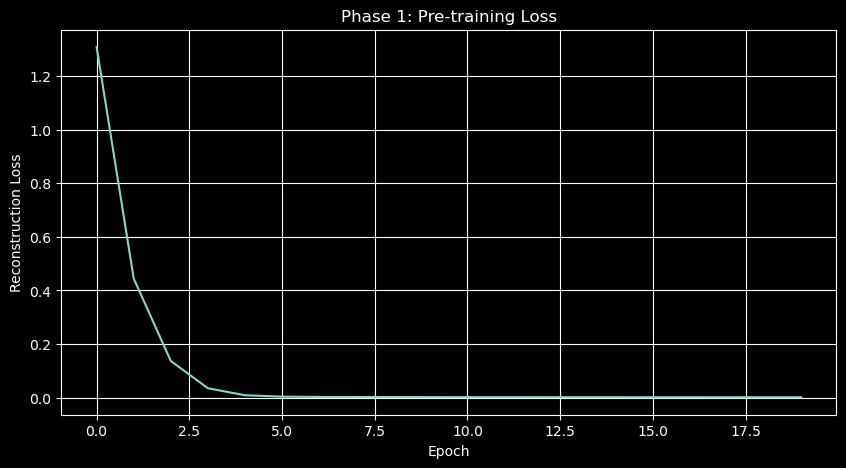

In [15]:
# Train Phase 1
phase1_losses = train_phase1(model, train_loader, num_epochs=20, lr=1e-3)

# Plot losses
plt.figure(figsize=(10, 5))
plt.plot(phase1_losses)
plt.xlabel('Epoch')
plt.ylabel('Reconstruction Loss')
plt.title('Phase 1: Pre-training Loss')
plt.grid(True)
plt.show()

### Phase 2: Main Training (DSVDD-style)

1. Compute center from training data
2. Train with combined loss: distance to center + reconstruction

In [16]:
def initialize_center(model, train_loader):
    """Compute center as mean of latent representations."""
    print('\nInitializing center...')
    
    model.eval()
    latents = []
    
    with torch.no_grad():
        for batch in tqdm(train_loader, desc='Computing center'):
            x = batch.to(device)
            z, _ = model.encode(x)
            latents.append(z)
    
    latents = torch.cat(latents, dim=0)
    center = latents.mean(dim=0)
    
    model.center = center
    model.center_initialized = True
    
    print(f'Center shape: {center.shape}')
    print(f'Center norm: {center.norm().item():.4f}')
    
    return center

In [17]:
def train_phase2WN(model, train_loader, num_epochs=100, lr=1e-4, alpha=0.1):
    """Phase 2: DSVDD-style manifold refinement + CosineAnnealingLR.
    
    CosineAnnealingLR gives a smooth, predictable glide to zero so the
    model gently packs latent representations into tight neighborhoods
    — ideal for deep k-NN distance search.
    """
    print('\n=== Phase 2: Main Training (DSVDD-style + CosineAnnealingLR) ===')
    
    # Initialize center
    initialize_center(model, train_loader)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=num_epochs,   # one full cosine cycle over all epochs
        eta_min=lr * 1e-2,  # floor: don't fall below 1 % of start lr
    )
    
    losses = []
    center_losses = []
    recon_losses = []
    
    for epoch in range(num_epochs):
        # Initialize center
        #initialize_center(model, train_loader)
        model.train()
        epoch_loss = 0
        epoch_center_loss = 0
        epoch_recon_loss = 0
        
        for batch in tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}'):
            x = batch.to(device)
            
            optimizer.zero_grad()
            
            # Compute reconstruction loss
            z,_ = model.encode(x)
            
            # Compute center loss (distance to center)
            center_loss = torch.mean(torch.sum((z - model.center) ** 2, dim=1))
            
            # Combined loss
            #loss = center_loss + alpha * recon_loss
            loss = center_loss
            
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            epoch_center_loss += center_loss.item()
            #epoch_recon_loss += recon_loss.item()
        
        scheduler.step()   # CosineAnnealingLR steps every epoch
        
        avg_loss = epoch_loss / len(train_loader)
        avg_center_loss = epoch_center_loss / len(train_loader)
        #avg_recon_loss = epoch_recon_loss / len(train_loader)
        
        losses.append(avg_loss)
        center_losses.append(avg_center_loss)
        #recon_losses.append(avg_recon_loss)
        
        current_lr = scheduler.get_last_lr()[0]
        print(f'Epoch {epoch+1}/{num_epochs}, '
              f'Loss: {avg_loss:.6f}, '
              f'Center: {avg_center_loss:.6f}, '
              #f'Recon: {avg_recon_loss:.6f}, '
              f'LR: {current_lr:.2e}')
    
    return losses, center_losses, recon_losses


In [18]:
def train_phase2(model, train_loader, num_epochs=100, lr=1e-4, alpha=0.1):
    """Phase 2: DSVDD-style manifold refinement + CosineAnnealingLR.
    
    CosineAnnealingLR gives a smooth, predictable glide to zero so the
    model gently packs latent representations into tight neighborhoods
    — ideal for deep k-NN distance search.
    """
    print('\n=== Phase 2: Main Training (DSVDD-style + CosineAnnealingLR) ===')
    
    # Initialize center
    initialize_center(model, train_loader)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=num_epochs,   # one full cosine cycle over all epochs
        eta_min=lr * 1e-2,  # floor: don't fall below 1 % of start lr
    )
    
    losses = []
    center_losses = []
    recon_losses = []
    
    for epoch in range(num_epochs):

        model.train()
        epoch_loss = 0
        epoch_center_loss = 0
        epoch_recon_loss = 0
        
        for batch in tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}'):

            x = batch.to(device)
            
            optimizer.zero_grad()
            
            # Compute reconstruction loss
            recon_loss, z = compute_reconstruction_loss(model, x)
            
            # Compute center loss (distance to center)
            center_loss = torch.mean(torch.sum((z - model.center) ** 2, dim=1))
            
            # Combined loss
            loss = center_loss + alpha * recon_loss
            
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            epoch_center_loss += center_loss.item()
            epoch_recon_loss += recon_loss.item()
        
        scheduler.step()   # CosineAnnealingLR steps every epoch
        
        avg_loss = epoch_loss / len(train_loader)
        avg_center_loss = epoch_center_loss / len(train_loader)
        avg_recon_loss = epoch_recon_loss / len(train_loader)
        
        losses.append(avg_loss)
        center_losses.append(avg_center_loss)
        recon_losses.append(avg_recon_loss)
        
        current_lr = scheduler.get_last_lr()[0]
        print(f'Epoch {epoch+1}/{num_epochs}, '
              f'Loss: {avg_loss:.6f}, '
              f'Center: {avg_center_loss:.6f}, '
              f'Recon: {avg_recon_loss:.6f}, '
              f'LR: {current_lr:.2e}')
    
    return losses, center_losses, recon_losses


Number of windows: 13

=== Phase 2: Main Training (DSVDD-style + CosineAnnealingLR) ===

Initializing center...


Computing center: 100%|██████████| 120/120 [00:00<00:00, 200.14it/s]


Center shape: torch.Size([32])
Center norm: 4.1584


Epoch 1/100: 100%|██████████| 120/120 [00:02<00:00, 54.44it/s]


Epoch 1/100, Loss: 0.549524, Center: 0.508445, Recon: 0.082157, LR: 1.00e-03


...

Epoch 98/100, Loss: 0.000646, Center: 0.000122, Recon: 0.001048, LR: 1.10e-05


Epoch 99/100: 100%|██████████| 120/120 [00:02<00:00, 56.13it/s]


Epoch 99/100, Loss: 0.000639, Center: 0.000117, Recon: 0.001044, LR: 1.02e-05


Epoch 100/100: 100%|██████████| 120/120 [00:02<00:00, 56.31it/s]


Epoch 100/100, Loss: 0.000648, Center: 0.000126, Recon: 0.001045, LR: 1.00e-05


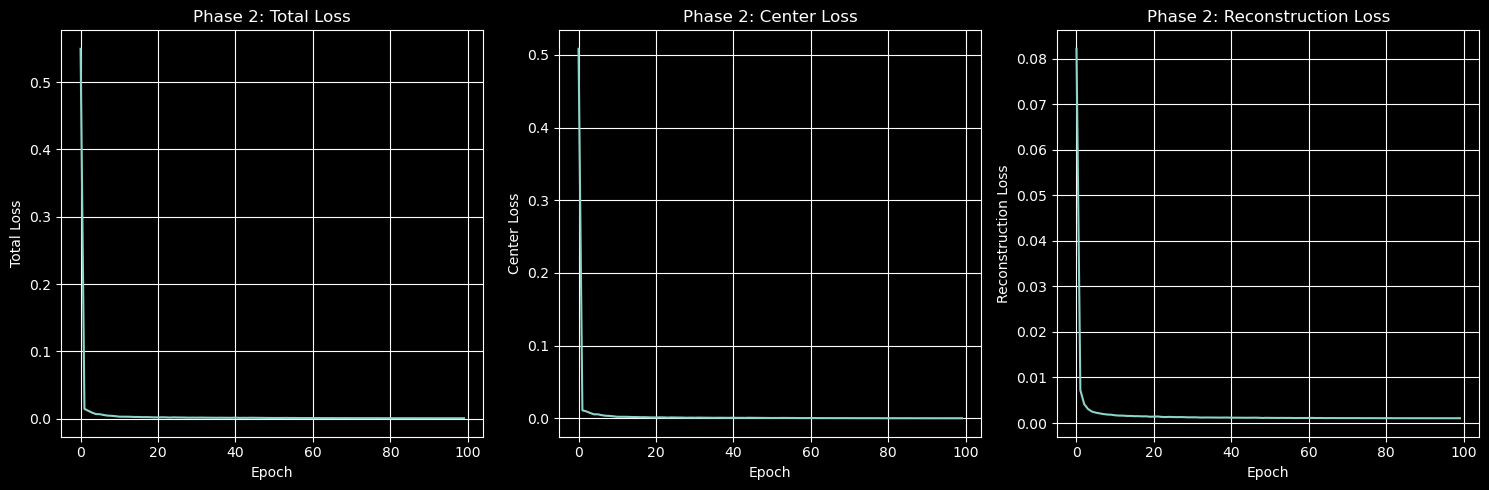

In [19]:
# Train Phase 2
model_ft = PA2EFT(model).to(device)
phase2_losses, phase2_center_losses, phase2_recon_losses = train_phase2(
    model_ft, train_loader, num_epochs=100, lr=1e-3, alpha=0.5
)

# Plot losses
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(phase2_losses)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Total Loss')
axes[0].set_title('Phase 2: Total Loss')
axes[0].grid(True)

axes[1].plot(phase2_center_losses)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Center Loss')
axes[1].set_title('Phase 2: Center Loss')
axes[1].grid(True)

axes[2].plot(phase2_recon_losses)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Reconstruction Loss')
axes[2].set_title('Phase 2: Reconstruction Loss')
axes[2].grid(True)

plt.tight_layout()
plt.show()

## 4. Inference and Evaluation

Anomaly score: ||z - c||²

In [20]:
import torch
from datetime import datetime
from scipy.ndimage import median_filter
from sklearn.metrics import precision_recall_curve, auc, roc_auc_score

# =======================================================
# PHASE 3: OFFLINE FITTING (Do this ONCE after training)
# =======================================================
print("\n--- Phase 3: Building Deep GPU Memory Bank ---")
def build_gpu_memory_bank(model, loader, device):
    model_ft.eval()
    bank = []
    with torch.no_grad():
        for batch in tqdm(loader, desc="Compiling Bank on GPU"):
            x = batch[0] if isinstance(batch, (list, tuple)) else batch
            # Extract latent z
            z, _ = model_ft.encode(x.to(device))
            bank.append(z)
            
    # Concatenate into a single massive tensor and KEEP IT ON THE GPU
    # Shape: (N_train_pixels, latent_dim)
    return torch.cat(bank, dim=0)

# Compile the bank and leave it in VRAM
memory_bank_gpu = build_gpu_memory_bank(model_ft, train_loader, device)
print(f"Memory Bank Shape: {memory_bank_gpu.shape} | Device: {memory_bank_gpu.device}")


# =======================================================
# PHASE 4: REAL-TIME INFERENCE (Blazing Fast)
# =======================================================
print("\n--- Phase 4: Fast Deep k-NN Inference ---")
start = datetime.now()

model_ft.eval()
all_scores = []
all_labels=[]
batch_times = []

with torch.no_grad():
    for batch in test_loader: # Removed tqdm so it doesn't slow down the loop
        start_batch = datetime.now()
        x, labels = batch
        x = x.to(device)
        
        # 1. Forward pass (extract z dynamically)
        z, _ = model_ft.encode(x) # Shape: (Batch, latent_dim)
        
        # 2. Native GPU k-NN (Calculates distance from Batch to entire Memory Bank instantly)
        # cdist computes the Euclidean distance matrix: (Batch, N_train_pixels)
        distances = torch.cdist(z, memory_bank_gpu, p=2.0)
        
        # 3. Get k=1 (minimum distance) for each pixel in the batch
        min_distances, _ = torch.min(distances, dim=1)
        
        # 4. Push ONLY the final scalar scores to CPU
        all_scores.append(min_distances.cpu())
        all_labels.append(labels)
        end_batch = datetime.now()
        batch_times.append((end_batch - start_batch).total_seconds())

# Concatenate all batch scores
anomaly_scores_deep_knn = torch.cat(all_scores).numpy()
all_labels = torch.cat(all_labels).numpy()
    
# Convert labels to binary (0=normal, 1=anomaly)
# Assuming label 2 is normal, others are anomalies
labels = (all_labels != 2).astype(int)

# Post-hoc spatial smoothing (CPU is fine here, it's just a tiny 2D matrix)
H, W = test_dataset.shape
score_map = anomaly_scores_deep_knn.reshape(H, W)
smoothed_score_map = median_filter(score_map, size=3)
smoothed_scores = smoothed_score_map.flatten()

end = datetime.now()

# =======================================================
# EVALUATION
# =======================================================
print(f"\n⚡ Time taken for Deep GPU k-NN + Smoothing: {end - start}")
knn_infer = end-start
print(f"Average time per batch: {np.mean(batch_times):.4f} ~ {np.std(batch_times):.4f} seconds")
print(f"Average time per pixel: {(end - start).total_seconds() / len(test_labels):.6f} seconds")

roc_auc_deep = roc_auc_score(labels, smoothed_scores)
precision_deep, recall_deep, _ = precision_recall_curve(labels, smoothed_scores)
pr_auc_deep = auc(recall_deep, precision_deep)

print(f"Deep GPU k-NN (Smoothed): ROC-AUC={roc_auc_deep:.4f}, PR-AUC={pr_auc_deep:.4f}")


--- Phase 3: Building Deep GPU Memory Bank ---


Compiling Bank on GPU: 100%|██████████| 120/120 [00:00<00:00, 181.44it/s]

Memory Bank Shape: torch.Size([61440, 32]) | Device: cuda:0

--- Phase 4: Fast Deep k-NN Inference ---



⚡ Time taken for Deep GPU k-NN + Smoothing: 0:00:02.340171
Average time per batch: 0.0044 ~ 0.0013 seconds
Average time per pixel: 0.000011 seconds
Deep GPU k-NN (Smoothed): ROC-AUC=0.9950, PR-AUC=0.9400


/tmp/ipykernel_108551/2653476721.py:143: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


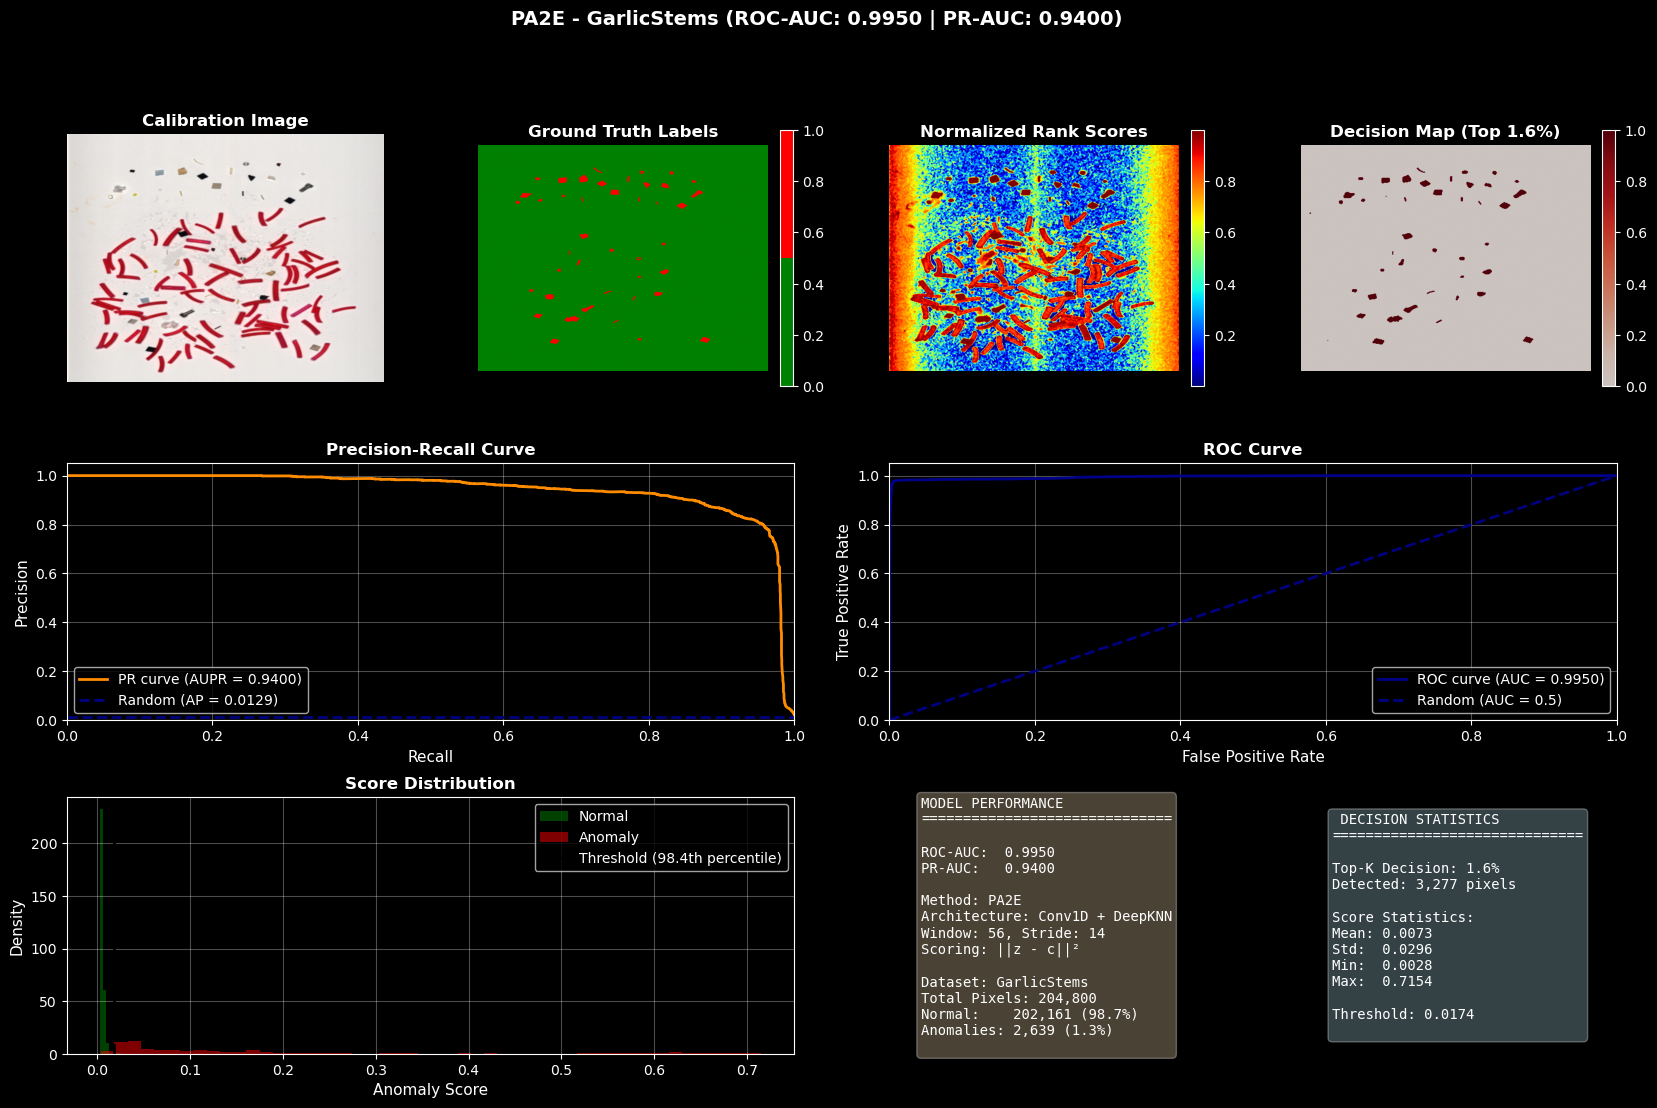


✅ Visualization complete!
   Top-K decision (1.6%): 3,277 pixels detected as anomalous


In [21]:
# Comprehensive visualization with multiple subplots
from scipy.stats import rankdata
from PIL import Image

# Load calibration image
calib_path = f'{base_path}/Test/image_calibration.png'

# Compute normalized rank scores for visualization
rank_scores = rankdata(smoothed_scores, method="average") / len(smoothed_scores)
normalized_scores = rank_scores
roc_auc = roc_auc_deep
pr_auc = pr_auc_deep

# Compute decision threshold (top K%)
TOP_K_PERCENT = 1.6  # Top 1% as anomalies
k_pixels = int(np.ceil(len(smoothed_scores) * TOP_K_PERCENT / 100.0))
top_k_indices = np.argsort(-smoothed_scores)[:k_pixels]
pixel_decision = np.zeros(len(smoothed_scores), dtype=bool)
pixel_decision[top_k_indices] = True

# Reshape for spatial visualization
H, W = test_dataset.shape
score_map = smoothed_scores.reshape(H, W)
normalized_score_map = normalized_scores.reshape(H, W)
label_map = labels.reshape(H, W)
decision_map = pixel_decision.reshape(H, W)

# Create comprehensive figure
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 4, hspace=0.3, wspace=0.3)

# Row 1: Spatial visualizations
ax1 = fig.add_subplot(gs[0, 0])
if os.path.exists(calib_path):
    calib_img = Image.open(calib_path)
    ax1.imshow(calib_img)
    ax1.set_title('Calibration Image', fontsize=12, fontweight='bold')
else:
    ax1.text(0.5, 0.5, 'Calibration Image\nNot Found', ha='center', va='center', fontsize=12)
    ax1.set_title('Calibration Image', fontsize=12, fontweight='bold')
ax1.axis('off')

ax2 = fig.add_subplot(gs[0, 1])
from matplotlib.colors import ListedColormap
cmap_binary = ListedColormap(['green', 'red'])
im2 = ax2.imshow(label_map, cmap=cmap_binary)
ax2.set_title('Ground Truth Labels', fontsize=12, fontweight='bold')
ax2.axis('off')
plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

ax3 = fig.add_subplot(gs[0, 2])
im3 = ax3.imshow(normalized_score_map, cmap='jet')
ax3.set_title('Normalized Rank Scores', fontsize=12, fontweight='bold')
ax3.axis('off')
plt.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04)

ax4 = fig.add_subplot(gs[0, 3])
im4 = ax4.imshow(decision_map, cmap='Reds', alpha=0.8)
ax4.set_title(f'Decision Map (Top {TOP_K_PERCENT}%)', fontsize=12, fontweight='bold')
ax4.axis('off')
plt.colorbar(im4, ax=ax4, fraction=0.046, pad=0.04)

# Row 2: PR and ROC curves
ax5 = fig.add_subplot(gs[1, 0:2])
precision, recall, _ = precision_recall_curve(labels, smoothed_scores)
ax5.plot(recall, precision, color='darkorange', lw=2, label=f'PR curve (AUPR = {pr_auc:.4f})')
baseline = labels.sum() / len(labels)
ax5.plot([0, 1], [baseline, baseline], color='navy', lw=2, linestyle='--', label=f'Random (AP = {baseline:.4f})')
ax5.set_xlim([0.0, 1.0])
ax5.set_ylim([0.0, 1.05])
ax5.set_xlabel('Recall', fontsize=11)
ax5.set_ylabel('Precision', fontsize=11)
ax5.set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
ax5.legend(loc='best')
ax5.grid(True, alpha=0.3)

ax6 = fig.add_subplot(gs[1, 2:4])
fpr, tpr, _ = roc_curve(labels, smoothed_scores)
ax6.plot(fpr, tpr, color='darkblue', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
ax6.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random (AUC = 0.5)')
ax6.set_xlim([0.0, 1.0])
ax6.set_ylim([0.0, 1.05])
ax6.set_xlabel('False Positive Rate', fontsize=11)
ax6.set_ylabel('True Positive Rate', fontsize=11)
ax6.set_title('ROC Curve', fontsize=12, fontweight='bold')
ax6.legend(loc='lower right')
ax6.grid(True, alpha=0.3)

# Row 3: Distribution and statistics
ax7 = fig.add_subplot(gs[2, 0:2])
ax7.hist(smoothed_scores[labels == 0], bins=50, alpha=0.5, label='Normal', color='green', density=True)
ax7.hist(smoothed_scores[labels == 1], bins=50, alpha=0.5, label='Anomaly', color='red', density=True)
ax7.axvline(np.percentile(smoothed_scores, 100 - TOP_K_PERCENT), color='black', linestyle='--', 
            label=f'Threshold ({100-TOP_K_PERCENT}th percentile)', linewidth=2)
ax7.set_xlabel('Anomaly Score', fontsize=11)
ax7.set_ylabel('Density', fontsize=11)
ax7.set_title('Score Distribution', fontsize=12, fontweight='bold')
ax7.legend()
ax7.grid(True, alpha=0.3)

ax8 = fig.add_subplot(gs[2, 2])
stats_text_left = f"""MODEL PERFORMANCE
{'='*30}

ROC-AUC:  {roc_auc:.4f}
PR-AUC:   {pr_auc:.4f}

Method: PA2E
Architecture: Conv1D + DeepKNN
Window: 56, Stride: 14
Scoring: ||z - c||²

Dataset: {food_type}
Total Pixels: {len(smoothed_scores):,}
Normal:    {(labels == 0).sum():,} ({100*(labels==0).sum()/len(labels):.1f}%)
Anomalies: {(labels == 1).sum():,} ({100*(labels==1).sum()/len(labels):.1f}%)
"""
ax8.text(0.1, 0.5, stats_text_left, fontsize=10, family='monospace', 
         verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
ax8.axis('off')

ax9 = fig.add_subplot(gs[2, 3])
stats_text_right = f""" DECISION STATISTICS
{'='*30}

Top-K Decision: {TOP_K_PERCENT}%
Detected: {pixel_decision.sum():,} pixels

Score Statistics:
Mean: {smoothed_scores.mean():.4f}
Std:  {smoothed_scores.std():.4f}
Min:  {smoothed_scores.min():.4f}
Max:  {smoothed_scores.max():.4f}

Threshold: {np.percentile(smoothed_scores, 100 - TOP_K_PERCENT):.4f}
"""
ax9.text(0.1, 0.5, stats_text_right, fontsize=10, family='monospace', 
         verticalalignment='center', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))
ax9.axis('off')

plt.suptitle(f'PA2E - {food_type} (ROC-AUC: {roc_auc:.4f} | PR-AUC: {pr_auc:.4f})', 
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print(f"\n✅ Visualization complete!")
print(f"   Top-K decision ({TOP_K_PERCENT}%): {pixel_decision.sum():,} pixels detected as anomalous")

## Conv+BN Execution Fusion (Layer Fusion)
Fuse Conv1d + BatchNorm1d pairs into single Conv1d layers for faster inference.
This is mathematically equivalent but eliminates BN overhead at test time.

In [22]:
import copy
from datetime import datetime
from scipy.ndimage import median_filter

# ──────────────────────────────────────────────────────────────────────────────
# Conv+BN Execution Fusion utilities
# ──────────────────────────────────────────────────────────────────────────────
@torch.no_grad()
def fuse_conv_bn_eval(conv: nn.Conv1d, bn: nn.BatchNorm1d) -> nn.Conv1d:
    """Fuse a Conv1d and BatchNorm1d into a single Conv1d for inference.

    Multiplies BN running statistics into the convolution weights/bias so that
    the fused layer produces mathematically identical output without the BN overhead.
    """
    assert not conv.training and not bn.training, "Both layers must be in eval mode"

    fused = nn.Conv1d(
        conv.in_channels, conv.out_channels, conv.kernel_size,
        stride=conv.stride, padding=conv.padding,
        dilation=conv.dilation, groups=conv.groups, bias=True,
    ).to(conv.weight.device)

    scale = bn.weight / torch.sqrt(bn.running_var + bn.eps)  # gamma / sqrt(var+eps)
    fused.weight.data = conv.weight.data * scale[:, None, None]
    conv_bias = conv.bias if conv.bias is not None else torch.zeros_like(bn.running_mean)
    fused.bias.data = scale * (conv_bias - bn.running_mean) + bn.bias
    return fused


def apply_conv_bn_fusion(model):
    """Deep-copy model and fuse all Conv1d+BN1d pairs in partial encoders (in-place on copy)."""
    model_fused = copy.deepcopy(model)
    model_fused.eval()
    for encoder_seq in model_fused.partial_encoders.encoders:
        pairs = [
            (i, i + 1)
            for i in range(len(encoder_seq) - 1)
            if isinstance(encoder_seq[i], nn.Conv1d) and isinstance(encoder_seq[i + 1], nn.BatchNorm1d)
        ]
        for conv_idx, bn_idx in pairs:
            encoder_seq[conv_idx] = fuse_conv_bn_eval(encoder_seq[conv_idx], encoder_seq[bn_idx])
            encoder_seq[bn_idx] = nn.Identity()
    return model_fused


# ──────────────────────────────────────────────────────────────────────────────
# Apply Conv+BN fusion to model_ft
# ──────────────────────────────────────────────────────────────────────────────
model_fused = apply_conv_bn_fusion(model_ft).to(device)

print("Original encoder[0]:")
print(model_ft.partial_encoders.encoders[0])
print("\nFused encoder[0]:")
print(model_fused.partial_encoders.encoders[0])

n_params_orig = sum(p.numel() for p in model_ft.parameters())
n_params_fused = sum(p.numel() for p in model_fused.parameters())
print(f"\nOriginal params: {n_params_orig:,}")
print(f"Fused params:    {n_params_fused:,}")


# ──────────────────────────────────────────────────────────────────────────────
# Re-run Deep GPU k-NN inference with fused model
# ──────────────────────────────────────────────────────────────────────────────
print("\n--- Building Memory Bank (fused model) ---")
memory_bank_fused = build_gpu_memory_bank(model_fused, train_loader, device)
print(f"Memory Bank Shape: {memory_bank_fused.shape} | Device: {memory_bank_fused.device}")

print("\n--- Fast Deep k-NN Inference (fused model) ---")
start = datetime.now()

model_fused.eval()
all_scores_fused = []

with torch.no_grad():
    for batch in test_loader:
        x = batch[0] if isinstance(batch, (list, tuple)) else batch
        x = x.to(device)
        z, _ = model_fused.encode(x)
        distances = torch.cdist(z, memory_bank_fused, p=2.0)
        min_distances, _ = torch.min(distances, dim=1)
        all_scores_fused.append(min_distances.cpu())

scores_fused = torch.cat(all_scores_fused).numpy()

H, W = test_dataset.shape
smoothed_fused = median_filter(scores_fused.reshape(H, W), size=3).flatten()

end = datetime.now()

# ──────────────────────────────────────────────────────────────────────────────
# Evaluate fused model
# ──────────────────────────────────────────────────────────────────────────────
roc_auc_fused = roc_auc_score(labels, smoothed_fused)
precision_f, recall_f, _ = precision_recall_curve(labels, smoothed_fused)
pr_auc_fused = auc(recall_f, precision_f)

print(f"\n⚡ Fused model inference time: {end - start}")
fused_infer = end - start
print(f"Fused Deep k-NN (Smoothed): ROC-AUC={roc_auc_fused:.4f}, PR-AUC={pr_auc_fused:.4f}")

# Compare with original
print(f"\n{'='*50}")
print(f"{'Metric':<20} {'Original':>12} {'Fused':>12}")
print(f"{'='*50}")
print(f"{'ROC-AUC':<20} {roc_auc_deep:>12.4f} {roc_auc_fused:>12.4f}")
print(f"{'PR-AUC':<20} {pr_auc_deep:>12.4f} {pr_auc_fused:>12.4f}")
print(f"{'TIME (s)':<20} {knn_infer.total_seconds():>12.4f} {fused_infer.total_seconds():>12.4f}")
print(f"{'='*50}")

Original encoder[0]:
Sequential(
  (0): Conv1d(1, 16, kernel_size=(3,), stride=(2,), padding=(1,))
  (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): Conv1d(16, 14, kernel_size=(3,), stride=(2,), padding=(1,))
  (4): BatchNorm1d(14, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (5): ReLU()
  (6): AdaptiveAvgPool1d(output_size=2)
  (7): Flatten(start_dim=1, end_dim=-1)
)

Fused encoder[0]:
Sequential(
  (0): Conv1d(1, 16, kernel_size=(3,), stride=(2,), padding=(1,))
  (1): Identity()
  (2): ReLU()
  (3): Conv1d(16, 14, kernel_size=(3,), stride=(2,), padding=(1,))
  (4): Identity()
  (5): ReLU()
  (6): AdaptiveAvgPool1d(output_size=2)
  (7): Flatten(start_dim=1, end_dim=-1)
)

Original params: 47,339
Fused params:    46,559

--- Building Memory Bank (fused model) ---


Compiling Bank on GPU: 100%|██████████| 120/120 [00:00<00:00, 197.69it/s]

Memory Bank Shape: torch.Size([61440, 32]) | Device: cuda:0

--- Fast Deep k-NN Inference (fused model) ---



⚡ Fused model inference time: 0:00:02.031511
Fused Deep k-NN (Smoothed): ROC-AUC=0.9953, PR-AUC=0.9398

Metric                   Original        Fused
ROC-AUC                    0.9950       0.9953
PR-AUC                     0.9400       0.9398
TIME (s)                   2.3402       2.0315


/tmp/ipykernel_108551/2298423684.py:143: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


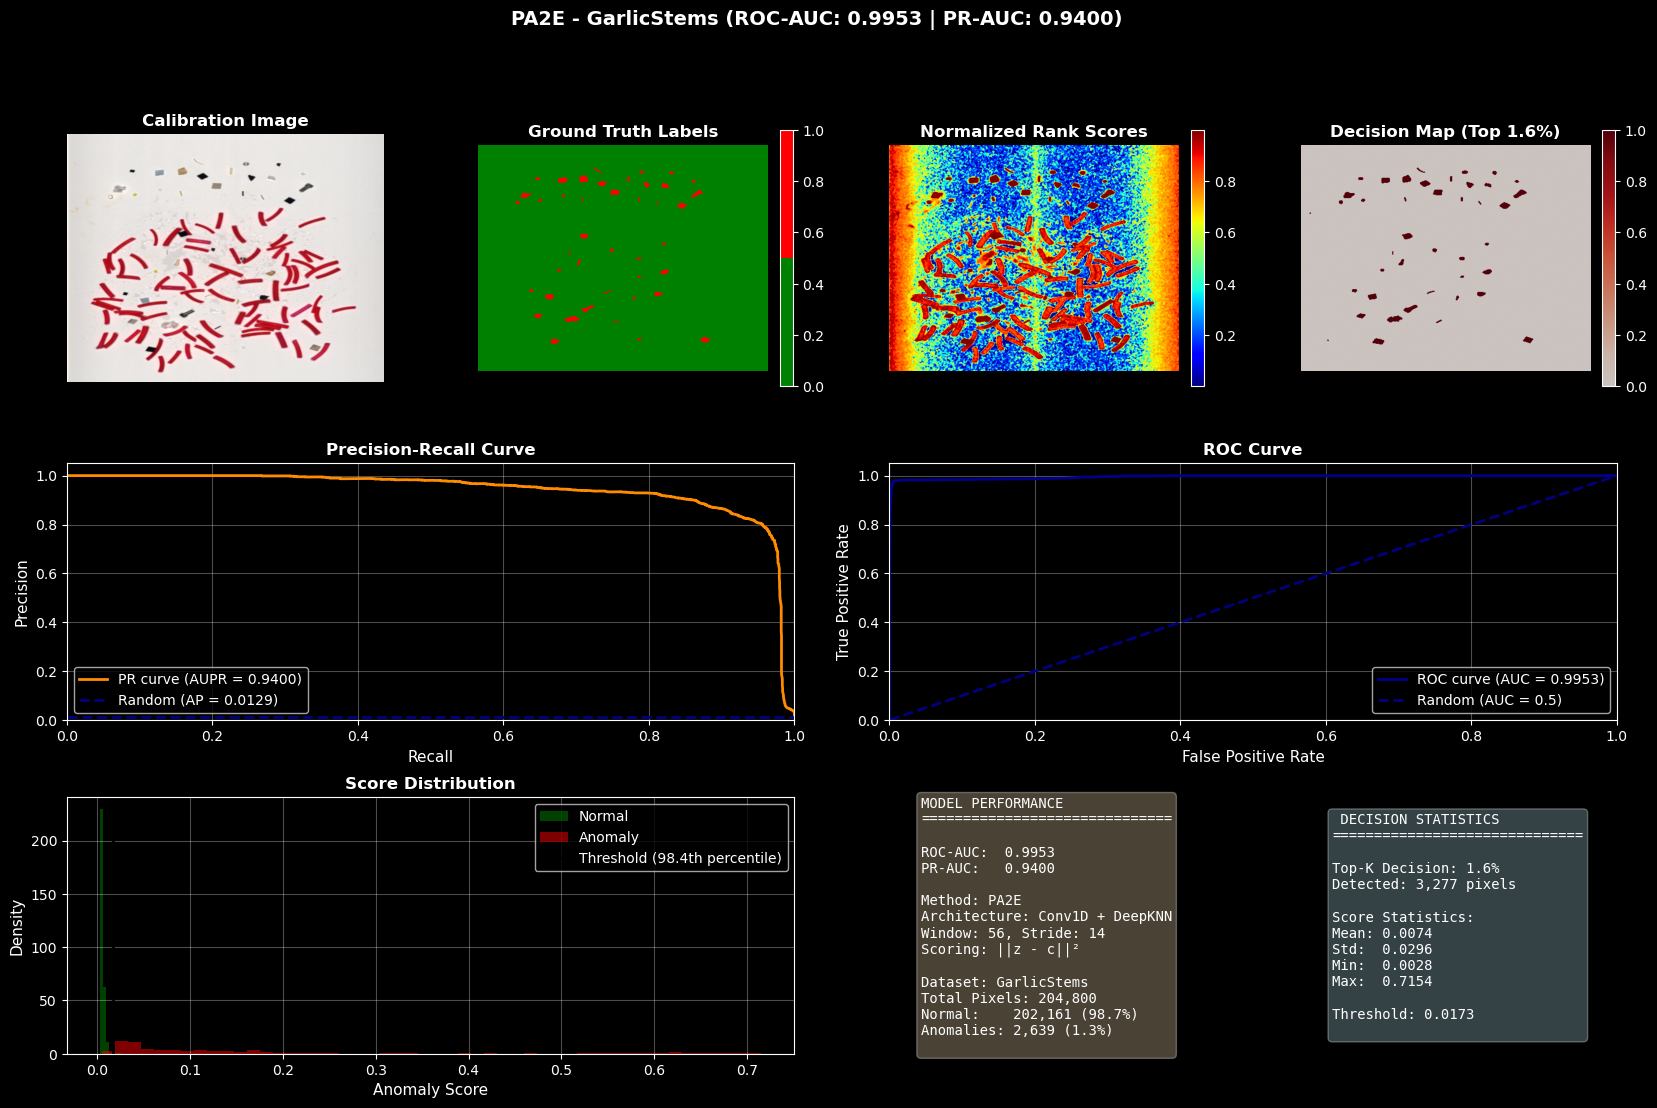


✅ Visualization complete!
   Top-K decision (1.6%): 3,277 pixels detected as anomalous


In [23]:
# Comprehensive visualization with multiple subplots
from scipy.stats import rankdata
from PIL import Image

# Load calibration image
calib_path = f'{base_path}/Test/image_calibration.png'

# Compute normalized rank scores for visualization
rank_scores = rankdata(smoothed_fused, method="average") / len(smoothed_fused)
normalized_scores = rank_scores
roc_auc = roc_auc_fused
pr_auc = pr_auc_deep

# Compute decision threshold (top K%)
TOP_K_PERCENT = 1.6  # Top 1% as anomalies
k_pixels = int(np.ceil(len(smoothed_fused) * TOP_K_PERCENT / 100.0))
top_k_indices = np.argsort(-smoothed_fused)[:k_pixels]
pixel_decision = np.zeros(len(smoothed_fused), dtype=bool)
pixel_decision[top_k_indices] = True

# Reshape for spatial visualization
H, W = test_dataset.shape
score_map = smoothed_fused.reshape(H, W)
normalized_score_map = normalized_scores.reshape(H, W)
label_map = labels.reshape(H, W)
decision_map = pixel_decision.reshape(H, W)

# Create comprehensive figure
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 4, hspace=0.3, wspace=0.3)

# Row 1: Spatial visualizations
ax1 = fig.add_subplot(gs[0, 0])
if os.path.exists(calib_path):
    calib_img = Image.open(calib_path)
    ax1.imshow(calib_img)
    ax1.set_title('Calibration Image', fontsize=12, fontweight='bold')
else:
    ax1.text(0.5, 0.5, 'Calibration Image\nNot Found', ha='center', va='center', fontsize=12)
    ax1.set_title('Calibration Image', fontsize=12, fontweight='bold')
ax1.axis('off')

ax2 = fig.add_subplot(gs[0, 1])
from matplotlib.colors import ListedColormap
cmap_binary = ListedColormap(['green', 'red'])
im2 = ax2.imshow(label_map, cmap=cmap_binary)
ax2.set_title('Ground Truth Labels', fontsize=12, fontweight='bold')
ax2.axis('off')
plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

ax3 = fig.add_subplot(gs[0, 2])
im3 = ax3.imshow(normalized_score_map, cmap='jet')
ax3.set_title('Normalized Rank Scores', fontsize=12, fontweight='bold')
ax3.axis('off')
plt.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04)

ax4 = fig.add_subplot(gs[0, 3])
im4 = ax4.imshow(decision_map, cmap='Reds', alpha=0.8)
ax4.set_title(f'Decision Map (Top {TOP_K_PERCENT}%)', fontsize=12, fontweight='bold')
ax4.axis('off')
plt.colorbar(im4, ax=ax4, fraction=0.046, pad=0.04)

# Row 2: PR and ROC curves
ax5 = fig.add_subplot(gs[1, 0:2])
precision, recall, _ = precision_recall_curve(labels, smoothed_fused)
ax5.plot(recall, precision, color='darkorange', lw=2, label=f'PR curve (AUPR = {pr_auc:.4f})')
baseline = labels.sum() / len(labels)
ax5.plot([0, 1], [baseline, baseline], color='navy', lw=2, linestyle='--', label=f'Random (AP = {baseline:.4f})')
ax5.set_xlim([0.0, 1.0])
ax5.set_ylim([0.0, 1.05])
ax5.set_xlabel('Recall', fontsize=11)
ax5.set_ylabel('Precision', fontsize=11)
ax5.set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
ax5.legend(loc='best')
ax5.grid(True, alpha=0.3)

ax6 = fig.add_subplot(gs[1, 2:4])
fpr, tpr, _ = roc_curve(labels, smoothed_fused)
ax6.plot(fpr, tpr, color='darkblue', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
ax6.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random (AUC = 0.5)')
ax6.set_xlim([0.0, 1.0])
ax6.set_ylim([0.0, 1.05])
ax6.set_xlabel('False Positive Rate', fontsize=11)
ax6.set_ylabel('True Positive Rate', fontsize=11)
ax6.set_title('ROC Curve', fontsize=12, fontweight='bold')
ax6.legend(loc='lower right')
ax6.grid(True, alpha=0.3)

# Row 3: Distribution and statistics
ax7 = fig.add_subplot(gs[2, 0:2])
ax7.hist(smoothed_fused[labels == 0], bins=50, alpha=0.5, label='Normal', color='green', density=True)
ax7.hist(smoothed_fused[labels == 1], bins=50, alpha=0.5, label='Anomaly', color='red', density=True)
ax7.axvline(np.percentile(smoothed_fused, 100 - TOP_K_PERCENT), color='black', linestyle='--', 
            label=f'Threshold ({100-TOP_K_PERCENT}th percentile)', linewidth=2)
ax7.set_xlabel('Anomaly Score', fontsize=11)
ax7.set_ylabel('Density', fontsize=11)
ax7.set_title('Score Distribution', fontsize=12, fontweight='bold')
ax7.legend()
ax7.grid(True, alpha=0.3)

ax8 = fig.add_subplot(gs[2, 2])
stats_text_left = f"""MODEL PERFORMANCE
{'='*30}

ROC-AUC:  {roc_auc:.4f}
PR-AUC:   {pr_auc:.4f}

Method: PA2E
Architecture: Conv1D + DeepKNN
Window: 56, Stride: 14
Scoring: ||z - c||²

Dataset: {food_type}
Total Pixels: {len(smoothed_fused):,}
Normal:    {(labels == 0).sum():,} ({100*(labels==0).sum()/len(labels):.1f}%)
Anomalies: {(labels == 1).sum():,} ({100*(labels==1).sum()/len(labels):.1f}%)
"""
ax8.text(0.1, 0.5, stats_text_left, fontsize=10, family='monospace', 
         verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
ax8.axis('off')

ax9 = fig.add_subplot(gs[2, 3])
stats_text_right = f""" DECISION STATISTICS
{'='*30}

Top-K Decision: {TOP_K_PERCENT}%
Detected: {pixel_decision.sum():,} pixels

Score Statistics:
Mean: {smoothed_fused.mean():.4f}
Std:  {smoothed_fused.std():.4f}
Min:  {smoothed_fused.min():.4f}
Max:  {smoothed_fused.max():.4f}

Threshold: {np.percentile(smoothed_fused, 100 - TOP_K_PERCENT):.4f}
"""
ax9.text(0.1, 0.5, stats_text_right, fontsize=10, family='monospace', 
         verticalalignment='center', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))
ax9.axis('off')

plt.suptitle(f'PA2E - {food_type} (ROC-AUC: {roc_auc:.4f} | PR-AUC: {pr_auc:.4f})', 
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print(f"\n✅ Visualization complete!")
print(f"   Top-K decision ({TOP_K_PERCENT}%): {pixel_decision.sum():,} pixels detected as anomalous")